# Add the Rybizki fidelity dataset

This notebook downloads the Rybizki Gaia fidelity catalog, unpacks the per-level `.npy` files, and turns the fidelity values into a Dask DataFrame keyed by `source_id`.

The main practical goal is to prepare a table with two columns:

- `source_id`: the Gaia source identifier, stored as `int64`.
- `fidelity_v2`: the fidelity value, stored as `float32` to keep memory use down.

The later cells assume that a Dask distributed client named `c` already exists in the notebook session. For example, create one with `c = Client()` for a local cluster or connect to a shared scheduler before scattering the partitions.

In [1]:
import numpy as np

## Download the catalog archive

The source archive is downloaded directly into the working directory as `fidelities.zip`. Run this from a machine or notebook environment with enough local disk space for both the zip file and the extracted `fidelities/` directory.

In [2]:
#! wget "https://keeper.mpdl.mpg.de/d/21d3582c0df94e19921d/files/?p=%2Fwhole_catalog_v2%2Ffidelities.zip&dl=1" -O fidelities.zip


In [3]:
#! python3 -c "import zipfile; zipfile.ZipFile('fidelities.zip').extractall('.')"

## Inspect one file

Before building a distributed table, inspect a representative `.npy` file to confirm the available fields and dtypes. The notebook expects each file to contain `source_id` and `fidelity_v2`.

In [ ]:
from pathlib import Path

fidelity_files = sorted(Path('fidelities').glob('lvl5_*.npy'))
if not fidelity_files:
    raise FileNotFoundError('No fidelity files found; download and extract the archive first.')

arr = np.load(fidelity_files[0])
print(arr.dtype.names)
# ('source_id', 'fidelity_v2')

('source_id', 'fidelity_v2')


## Build coarse partitions locally

The fidelity catalog is split across many small `.npy` files. Submitting every file as its own Dask task would create a very large task graph and spend too much time in scheduler overhead. This cell groups the files into a smaller number of pandas DataFrames first, then uses those DataFrames as the eventual Dask partitions.

The casts are intentional: `source_id` becomes a stable integer key, while `fidelity_v2` is kept as `float32` to reduce the amount of data scattered to workers.

In [5]:
import glob
import numpy as np
import pandas as pd
import dask.dataframe as dd
from dask import delayed
import time

# Grab all files
files = sorted(glob.glob('fidelities/lvl5_*.npy'))


def load_one(fpath):
    arr = np.load(fpath)
    return pd.DataFrame({
        'source_id': arr['source_id'].astype('int64'),
        'fidelity_v2': arr['fidelity_v2'].astype('float32'),
    })

# Batch files into ~200 chunks rather than scattering 12,000 tiny pieces —
# reduces scheduler overhead significantly
n_chunks = 200
chunks = np.array_split(files, n_chunks)

_t1 = time.time()

partitions = []
for chunk_files in chunks:
    dfs = [load_one(f) for f in chunk_files]
    partitions.append(pd.concat(dfs, ignore_index=True))

print('Time elapsed: ',time.time()-_t1)



Time elapsed:  198.83199501037598


## Scatter partitions to workers

This step sends the prepared pandas partitions to the connected Dask cluster. It uses small batches so the client does not try to push every partition at once. 

In [ ]:
from dask.distributed import Client

# This default address is specific to AstroFlow's in-cluster Dask operator.
scheduler_address = os.environ.get(
    'DASK_SCHEDULER_ADDRESS',
    'tcp://simple-scheduler.dask-operator.svc.cluster.local:8786',
)
c = Client(scheduler_address)
print(c)

<Client: 'tcp://172.19.205.29:8786' processes=10 threads=50, memory=700.00 GiB>


/opt/conda/lib/python3.12/site-packages/distributed/client.py:1590: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| numpy   | 2.0.2  | 2.2.6     | 2.2.6   |
| toolz   | 1.0.0  | 0.12.0    | 0.12.0  |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


In [7]:
futures = []
batch_size = 10  # scatter a handful at a time, not all 200 at once
for i in range(0, len(partitions), batch_size):
    batch = partitions[i:i+batch_size]
    futures.extend(c.scatter(batch))

## Wrap futures as a Dask DataFrame

Each scattered pandas DataFrame is represented by a future. Wrapping the futures with `delayed` lets `dd.from_delayed` assemble them into one logical Dask DataFrame. Supplying `meta` gives Dask the schema up front, so it does not need to execute a sample task just to infer column names and dtypes.

In [8]:
import dask.dataframe as dd
from dask import delayed

# Wrap each future as a delayed object so dask.dataframe knows how to treat it
delayed_dfs = [delayed(f) for f in futures]

# Need meta - the empty-frame schema - to avoid dask inspecting data itself
meta = partitions[0].iloc[:0]  # empty DataFrame with correct columns/dtypes

ddf = dd.from_delayed(delayed_dfs, meta=meta)

print(ddf.npartitions)  # should match len(futures)
print(ddf.dtypes)

200
source_id        int64
fidelity_v2    float32
dtype: object


## Index by Gaia source id

Setting `source_id` as the index makes later joins and lookups by Gaia source id more natural. This is also the expensive distributed step: Dask has to shuffle rows between partitions so that the index ordering and partition divisions are consistent.

In [9]:
_t1 = time.time()

ddf = ddf.set_index('source_id')  # shuffle happens here

print('Time elapsed: ',time.time()-_t1)


Time elapsed:  0.001392364501953125


## Preview the result

`head()` pulls a small sample back to the notebook process. At this point, check that the index is `source_id`, the `fidelity_v2` column is present, and the values look plausible before writing the dataset out or joining it with other Gaia tables.

In [10]:
ddf.head()

,fidelity_v2
source_id,
4295806720,0.999512
34361129088,1.000000
38655544960,1.000000
309238066432,0.984863
343597448960,1.000000


## Cross-match against Gaia RVS

The next cells join the fidelity table to a filtered subset of Gaia DR3 sources with radial velocities. This gives a working sample with usable astrometry, an available `radial_velocity`, and the Rybizki `fidelity_v2` value attached by `source_id`.

The Gaia source data is read from parquet using `DASK_DATA_PATH_GAIA_DR3_SSD`, so that environment variable needs to point at the local or mounted Gaia DR3 data root.

In [11]:
from pathlib import Path
import os

source_cols = ['source_id', 'ra', 'dec',
               'phot_g_mean_mag', 'bp_rp',
               'parallax', 'parallax_over_error',
               'ruwe', 'astrometric_excess_noise_sig',
               'astrometric_gof_al', 'astrometric_sigma5d_max',
               'visibility_periods_used', 'ipd_frac_multi_peak',
               'ipd_gof_harmonic_amplitude',
               'phot_bp_rp_excess_factor', 'duplicated_source',
               'radial_velocity', 'rv_nb_transits',
               'rv_chisq_pvalue', 'rv_renormalised_gof']

data_root = os.environ.get('DASK_DATA_PATH_GAIA_DR3_SSD')
if not data_root:
    raise ValueError('DASK_DATA_PATH_GAIA_DR3_SSD is not set; point it at the Gaia DR3 data root')

gaia_source = dd.read_parquet(Path(data_root).joinpath('GDR3_GAIA_SOURCE/'), 
                           columns=source_cols)


gaia_source = gaia_source[
    gaia_source["radial_velocity"].notnull()
].persist()

## Attach fidelity values

Only the columns needed for the cross-match and quality checks are loaded from Gaia. The filters are persisted in two stages to keep the working set smaller before the join. The inner merge keeps sources that appear in both the filtered Gaia RVS sample and the fidelity catalog.

In [12]:
# set up to do the merge
result = gaia_source.merge(ddf, on="source_id", how="inner")

## Materialize the matched sample

The merge is still lazy until `compute()` runs. This brings the matched subset back into the notebook process as a pandas DataFrame, so it is best done after the Gaia filters have made the result small enough to fit in memory.

In [13]:
_t1 = time.time()

smalldf = result.compute()

print('Time elapsed: ',time.time()-_t1)

# this has been chopped down a bit already, but let's just see how much time it takes
# took 101s to do the merge, but without the partition mapping will probably take longer

Time elapsed:  138.27642107009888


## Preview the cross-match

A quick `head()` check should show Gaia columns plus the joined `fidelity_v2` value. This is a lightweight sanity check before summarizing the fidelity distribution.

In [14]:
smalldf.head()

,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_over_error,ruwe,astrometric_excess_noise_sig,astrometric_gof_al,...,visibility_periods_used,ipd_frac_multi_peak,ipd_gof_harmonic_amplitude,phot_bp_rp_excess_factor,duplicated_source,radial_velocity,rv_nb_transits,rv_chisq_pvalue,rv_renormalised_gof,fidelity_v2
0,108623231904874240,45.161453,21.573734,14.619289,1.274325,1.326786,58.421318,0.954148,0.000000e+00,-0.955548,...,15,0,0.030917,1.249145,False,-44.304306,19.0,NaN,NaN,1.000000
1,139021155000719616,46.361099,36.660011,14.207475,1.017244,0.635703,12.561055,2.160768,3.135473e+01,19.870470,...,13,0,0.028366,1.222895,False,56.162300,11.0,NaN,NaN,0.986816
2,211446909340744064,87.646234,49.760643,14.377593,0.972508,0.617541,28.944677,0.955665,1.914017e-15,-1.304166,...,17,0,0.048695,1.216817,False,-10.352362,32.0,NaN,NaN,1.000000
3,230976370451797248,58.173158,41.555616,14.586014,1.243361,1.706053,66.836174,1.073609,1.140975e+00,1.954985,...,18,0,0.014622,1.241968,False,-81.345261,21.0,NaN,NaN,1.000000
4,257095956365924736,66.100765,46.790305,13.101514,1.168354,3.082614,43.940884,4.754142,2.490414e+02,75.190895,...,20,47,0.043314,1.591192,False,-12.793384,4.0,NaN,NaN,1.000000


## Locate the 0.5 fidelity threshold

To understand how strict a `fidelity_v2 = 0.5` threshold is for this matched sample, compute the empirical percentile rank of 0.5 among finite fidelity values. This reports the percentile closest to the threshold rather than guessing a fixed percentile by hand.

In [15]:
target_fidelity = 0.5
fidelity = smalldf['fidelity_v2'].to_numpy()
finite_fidelity = fidelity[np.isfinite(fidelity)]
if len(finite_fidelity) == 0:
    raise ValueError('No finite fidelity_v2 values found in smalldf')

sorted_fidelity = np.sort(finite_fidelity)
percentile_at_target = 100.0 * np.searchsorted(
    sorted_fidelity,
    target_fidelity,
    side='right',
) / len(sorted_fidelity)
nearest_percentile_value = np.nanpercentile(
    finite_fidelity,
    percentile_at_target,
)

print(f'fidelity_v2 = {target_fidelity} is closest to the {percentile_at_target:.3f}th percentile')
print(f'np.nanpercentile(..., {percentile_at_target:.3f}) = {nearest_percentile_value:.6f}')

fidelity_v2 = 0.5 is closest to the 4.172th percentile
np.nanpercentile(..., 4.172) = 0.500468


Running this notebook results in the discovery that only 4% of the entire RVS dataset is flagged as having bad astrometry!

In [16]:
smalldf.to_parquet('data/rvs_joined_rybizki.parquet', engine='pyarrow', compression='zstd')

In [17]:
import pandas as pd
smalldf = pd.read_parquet('data/rvs_joined_rybizki.parquet', engine='pyarrow')

There are some frankly surprising results to be found here, including sources with very high ruwe but still classified as good.

In [18]:
import easy2dhist
import matplotlib.cm as cm
import matplotlib.pyplot as plt


In [19]:
badruwe = smalldf[smalldf['ruwe']>3.0]
goodfidelity_badruwe = badruwe[badruwe['fidelity_v2']>0.99]
print('There are',goodfidelity_badruwe.shape[0],'sources with extremely high ruwe, but high fidelity measurements.')

There are 686096 sources with extremely high ruwe, but high fidelity measurements.


/home/jovyan/easy2dhist.py:57: RuntimeWarning: invalid value encountered in cast
  ix = ((x - xmin) / (xmax - xmin) * nx).astype(int)
/tmp/ipykernel_846/3725364983.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(H.T), extent=extent,aspect='auto',origin='lower',cmap=cm.Greys)


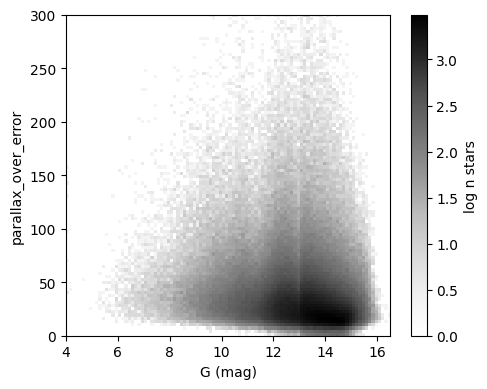

In [20]:
extent = [4,16.5,0,300]
H, xedges, yedges = easy2dhist.hist2d_raw(goodfidelity_badruwe['phot_g_mean_mag'],goodfidelity_badruwe['parallax_over_error'], bins=(100, 100),xrange=(extent[0],extent[1]),yrange=(extent[2],extent[3]))

plt.figure(figsize=(5,4))
plt.imshow(np.log10(H.T), extent=extent,aspect='auto',origin='lower',cmap=cm.Greys)
plt.xlabel('G (mag)')
plt.ylabel('parallax_over_error')
plt.colorbar(label='log n stars')
plt.tight_layout()

This feels like a puzzle!

## HR diagram of the selected sources

Construct an observational HR diagram for the high-fidelity (`fidelity_v2 > 0.99`), high-RUWE (`ruwe > 3`) sample selected above. The absolute G magnitude is calculated directly from the parallax in milliarcseconds, so this plot keeps only finite, positive parallaxes with `parallax_over_error > 5`. The fixed plotting limits suppress a small number of extreme outliers. No extinction or parallax zero-point correction is applied, so this is intended as a diagnostic rather than a precision colour-magnitude diagram.


In [21]:
import numpy as np
from matplotlib.colors import LogNorm

hr = goodfidelity_badruwe.loc[:, ['bp_rp', 'phot_g_mean_mag', 'parallax', 'parallax_over_error']].copy()
hr = hr.replace([np.inf, -np.inf], np.nan).dropna()
hr = hr[(hr['parallax'] > 0) & (hr['parallax_over_error'] > 5)].copy()
hr['absolute_g_mag'] = (
    hr['phot_g_mean_mag'] + 5 * np.log10(hr['parallax']) - 10
)
hr = hr[
    hr['bp_rp'].between(-1, 5)
    & hr['absolute_g_mag'].between(-5, 15)
]

print(f'{len(hr):,} of {len(goodfidelity_badruwe):,} selected sources pass the HR-diagram cuts.')

678,045 of 686,096 selected sources pass the HR-diagram cuts.


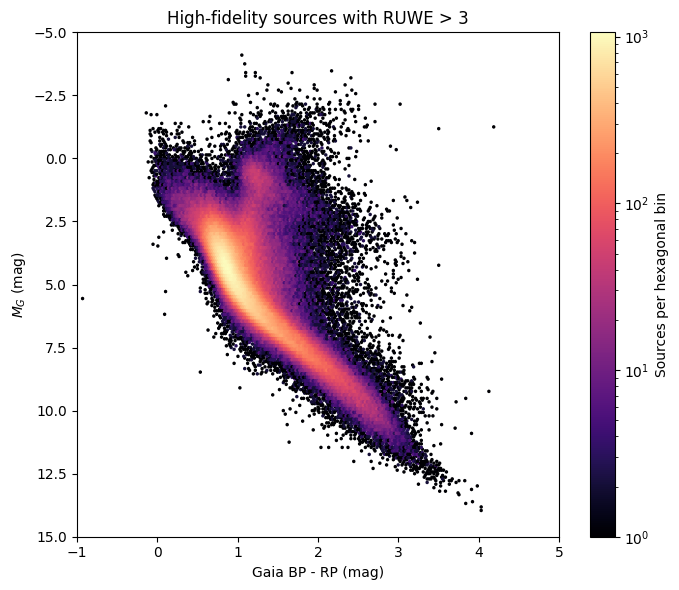

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
density = ax.hexbin(
    hr['bp_rp'],
    hr['absolute_g_mag'],
    gridsize=250,
    extent=(-1, 5, -5, 15),
    mincnt=1,
    norm=LogNorm(),
    cmap='magma',
)
ax.set(
    xlabel='Gaia BP - RP (mag)',
    ylabel=r'$M_G$ (mag)',
    title='High-fidelity sources with RUWE > 3',
)
ax.set_xlim(-1, 5)
ax.set_ylim(15, -5)
fig.colorbar(density, ax=ax, label='Sources per hexagonal bin')
fig.tight_layout()
plt.savefig('highruwesources.png',dpi=300)


## Cluster the Gaia quality indicators

Test whether the high-RUWE, high-fidelity population occupies unusual regions of the other Gaia quality indicators. To avoid building the answer into the model, neither RUWE nor fidelity is used as a clustering feature. Instead, a balanced sample is assembled from the target population and a high-fidelity control population with `0.8 <= ruwe <= 1.2`.

The features are median-imputed, clipped to their 0.5th and 99.5th percentiles, standardized, projected to two dimensions with PCA, and grouped with mini-batch k-means. Cluster labels have no physical ordering. A cluster enriched in target sources identifies a combination of indicators worth inspecting; the standardized feature-profile plot shows which dimensions drive it. Missing-value rates are reported separately because missingness can itself be informative, but it is not used to form the clusters.

This section requires scikit-learn. Rerun the Gaia read, join, and parquet-writing cells first so the saved table contains the expanded quality columns.

In [23]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

quality_features = [
    'parallax_over_error',
    'astrometric_excess_noise_sig',
    'astrometric_gof_al',
    'astrometric_sigma5d_max',
    'visibility_periods_used',
    'ipd_frac_multi_peak',
    'ipd_gof_harmonic_amplitude', 
    'phot_bp_rp_excess_factor',
    'duplicated_source',
    'rv_nb_transits',
    'rv_chisq_pvalue',
    'rv_renormalised_gof',
]

target_pool = goodfidelity_badruwe
control_pool = smalldf[
    (smalldf['fidelity_v2'] > 0.99)
    & smalldf['ruwe'].between(0.8, 1.2)
]
n_per_group = min(100_000, len(target_pool), len(control_pool))
if n_per_group == 0:
    raise ValueError('The target or control selection is empty.')

target_sample = target_pool.sample(n=n_per_group, random_state=42).copy()
target_sample['sample_group'] = 'high RUWE'
control_sample = control_pool.sample(n=n_per_group, random_state=42).copy()
control_sample['sample_group'] = 'control'
cluster_sample = pd.concat([target_sample, control_sample], ignore_index=True)
print(f'Clustering {len(cluster_sample):,} sources ({n_per_group:,} per group).')

Clustering 200,000 sources (100,000 per group).


In [24]:
feature_data = cluster_sample[quality_features].copy()
feature_data['duplicated_source'] = feature_data['duplicated_source'].astype(float)
feature_data = feature_data.replace([np.inf, -np.inf], np.nan)

missing_by_group = (
    feature_data.isna()
    .assign(sample_group=cluster_sample['sample_group'].to_numpy())
    .groupby('sample_group')
    .mean()
    .T
    .sort_values('high RUWE', ascending=False)
)
#display(missing_by_group.style.format('{:.1%}').set_caption('Missing fraction by sample'))

imputer = SimpleImputer(strategy='median', keep_empty_features=True)
X_imputed = pd.DataFrame(
    imputer.fit_transform(feature_data),
    columns=quality_features,
    index=feature_data.index,
)
lower = X_imputed.quantile(0.005)
upper = X_imputed.quantile(0.995)
X_clipped = X_imputed.clip(lower=lower, upper=upper, axis='columns')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clipped)

In [25]:
n_clusters = 6
cluster_model = MiniBatchKMeans(
    n_clusters=n_clusters,
    batch_size=4096,
    n_init=10,
    random_state=42,
)
cluster_sample['cluster'] = cluster_model.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
pca_coordinates = pca.fit_transform(X_scaled)
cluster_sample[['PC1', 'PC2']] = pca_coordinates
print(f'PC1 + PC2 explain {pca.explained_variance_ratio_.sum():.1%} of the standardized variance.')

PC1 + PC2 explain 41.5% of the standardized variance.


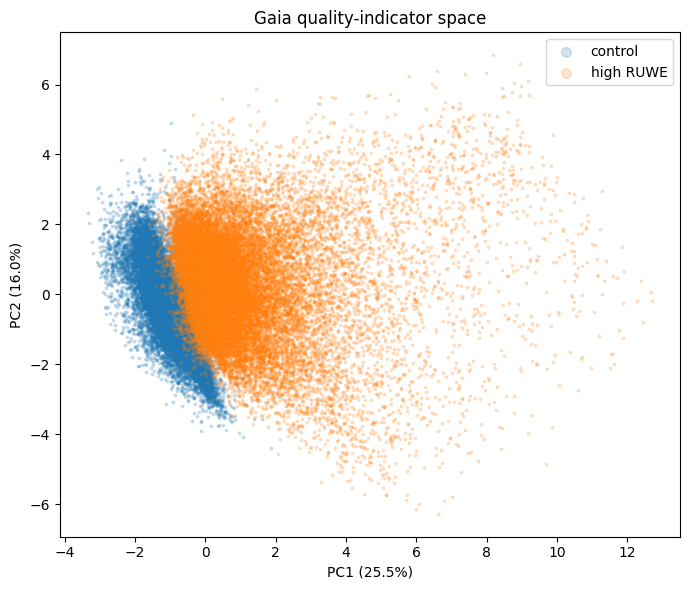

In [26]:
plot_sample = cluster_sample.sample(n=min(50_000, len(cluster_sample)), random_state=7)
colours = {'control': 'tab:blue', 'high RUWE': 'tab:orange'}

fig, ax = plt.subplots(figsize=(7, 6))
for group, points in plot_sample.groupby('sample_group'):
    ax.scatter(
        points['PC1'], points['PC2'],
        s=3, alpha=0.2, rasterized=True,
        color=colours[group], label=group,
    )
ax.set(
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
    title='Gaia quality-indicator space',
)
ax.legend(markerscale=4)
fig.tight_layout()

In [27]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=quality_features,
    columns=['PC1', 'PC2'],
)

for component in ['PC1', 'PC2']:
    print(f'\n{component}')
    display(
        pca_loadings[component]
        .sort_values(key=abs, ascending=False)
        .to_frame('loading')
    )


PC1


,loading
astrometric_sigma5d_max,0.524586
astrometric_gof_al,0.483106
astrometric_excess_noise_sig,0.452128
ipd_frac_multi_peak,0.305392
phot_bp_rp_excess_factor,0.249909
ipd_gof_harmonic_amplitude,0.246640
parallax_over_error,-0.184202
rv_nb_transits,-0.136513
rv_renormalised_gof,0.102457
rv_chisq_pvalue,-0.070119



PC2


,loading
rv_nb_transits,0.531184
visibility_periods_used,0.495689
ipd_gof_harmonic_amplitude,-0.368882
astrometric_gof_al,0.281597
phot_bp_rp_excess_factor,-0.273636
astrometric_excess_noise_sig,0.260504
rv_renormalised_gof,0.215609
ipd_frac_multi_peak,-0.188443
duplicated_source,0.115195
astrometric_sigma5d_max,0.087654


## On-sky distribution of the selected sources

Map the high-RUWE (`ruwe > 3`), high-fidelity (`fidelity_v2 > 0.99`) selection in Galactic coordinates. Astropy transforms the Gaia ICRS positions to Galactic longitude and latitude. Counts are accumulated in equal-solid-angle bins that are uniform in longitude and `sin(b)`, then displayed with a Mollweide projection and logarithmic colour scaling. Galactic longitude increases toward the left, following the usual astronomical convention.

Rerun the Gaia read, join, and parquet-writing cells after adding `ra` and `dec` to `source_cols`.

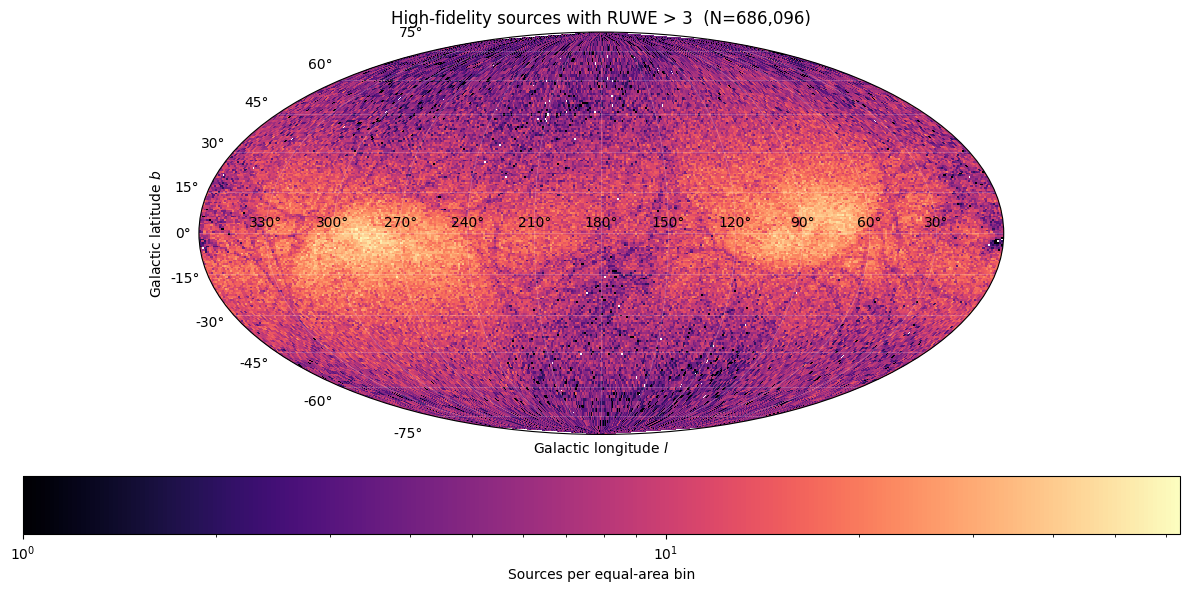

In [28]:
from astropy.coordinates import SkyCoord
import astropy.units as u

sky = goodfidelity_badruwe[['ra', 'dec']].replace([np.inf, -np.inf], np.nan).dropna()
sky = sky[sky['dec'].between(-90, 90)]

icrs_coordinates = SkyCoord(
    ra=sky['ra'].to_numpy() * u.deg,
    dec=sky['dec'].to_numpy() * u.deg,
    frame='icrs',
)
galactic = icrs_coordinates.galactic

# Centre the map at l=180 degrees and reverse longitude so l increases leftward.
longitude = np.deg2rad(180.0 - galactic.l.deg)
longitude = (longitude + np.pi) % (2 * np.pi) - np.pi
sin_latitude = np.sin(galactic.b.radian)

sky_counts, lon_edges, sin_latitude_edges = np.histogram2d(
    longitude, sin_latitude,
    bins=(360, 180),
    range=((-np.pi, np.pi), (-1, 1)),
)
latitude_edges = np.arcsin(sin_latitude_edges)
lon_grid, latitude_grid = np.meshgrid(lon_edges, latitude_edges, indexing='ij')
masked_counts = np.ma.masked_equal(sky_counts, 0)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
density = ax.pcolormesh(
    lon_grid, latitude_grid, masked_counts,
    norm=LogNorm(vmin=1, vmax=masked_counts.max()),
    cmap='magma', shading='auto', rasterized=True,
)
longitude_tick_locations = np.deg2rad(np.arange(-150, 180, 30))
longitude_tick_labels = [
    f'{int((180 - np.rad2deg(x)) % 360)}°' for x in longitude_tick_locations
]
ax.set_xticks(longitude_tick_locations, labels=longitude_tick_labels)
ax.set_xlabel(r'Galactic longitude $l$')
ax.set_ylabel(r'Galactic latitude $b$')
ax.set_title(f'High-fidelity sources with RUWE > 3  (N={len(sky):,})')
ax.grid(color='white', alpha=0.25, linewidth=0.5)
fig.colorbar(density, ax=ax, orientation='horizontal', pad=0.08, label='Sources per equal-area bin')
fig.tight_layout()
plt.savefig('highruwe_locations.png',dpi=300)

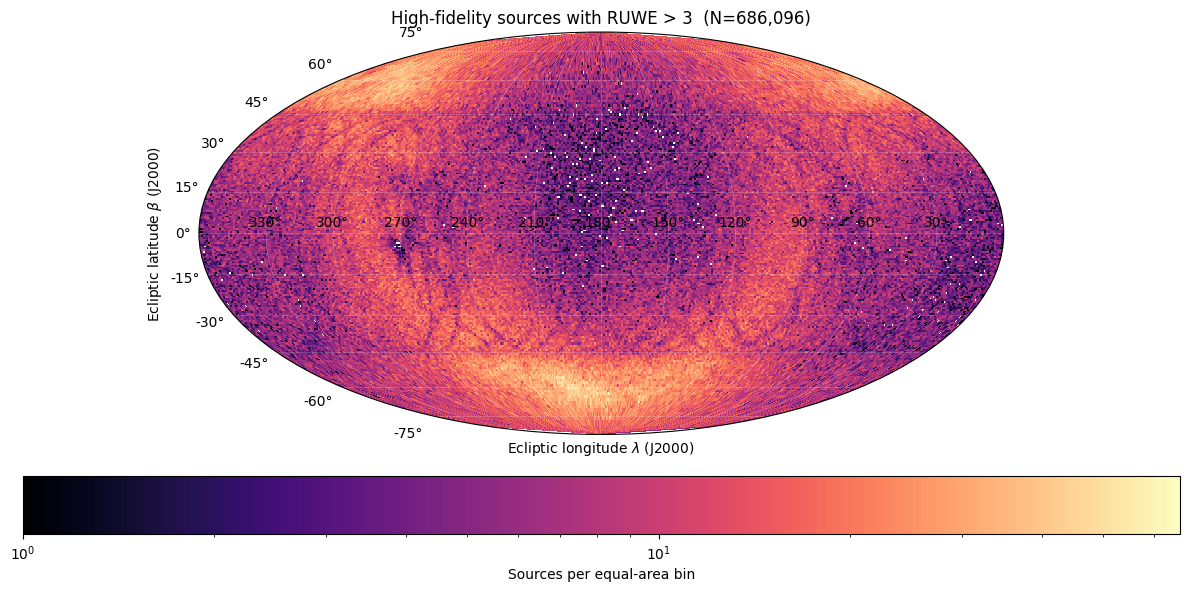

In [29]:
from astropy.coordinates import BarycentricMeanEcliptic
from astropy.time import Time

ecliptic = icrs_coordinates.transform_to(
    BarycentricMeanEcliptic(equinox=Time('J2000'))
)

# Centre the map at lambda=180 degrees and reverse longitude.
ecliptic_longitude = np.deg2rad(180.0 - ecliptic.lon.deg)
ecliptic_longitude = (ecliptic_longitude + np.pi) % (2 * np.pi) - np.pi
sin_ecliptic_latitude = np.sin(ecliptic.lat.radian)

ecliptic_counts, ecliptic_lon_edges, sin_ecliptic_latitude_edges = np.histogram2d(
    ecliptic_longitude, sin_ecliptic_latitude,
    bins=(360, 180),
    range=((-np.pi, np.pi), (-1, 1)),
)
ecliptic_latitude_edges = np.arcsin(sin_ecliptic_latitude_edges)
ecliptic_lon_grid, ecliptic_latitude_grid = np.meshgrid(
    ecliptic_lon_edges, ecliptic_latitude_edges, indexing='ij'
)
masked_ecliptic_counts = np.ma.masked_equal(ecliptic_counts, 0)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
density = ax.pcolormesh(
    ecliptic_lon_grid, ecliptic_latitude_grid, masked_ecliptic_counts,
    norm=LogNorm(vmin=1, vmax=masked_ecliptic_counts.max()),
    cmap='magma', shading='auto', rasterized=True,
)
longitude_tick_locations = np.deg2rad(np.arange(-150, 180, 30))
longitude_tick_labels = [
    f'{int((180 - np.rad2deg(x)) % 360)}°' for x in longitude_tick_locations
]
ax.set_xticks(longitude_tick_locations, labels=longitude_tick_labels)
ax.set_xlabel(r'Ecliptic longitude $\lambda$ (J2000)')
ax.set_ylabel(r'Ecliptic latitude $\beta$ (J2000)')
ax.set_title(f'High-fidelity sources with RUWE > 3  (N={len(sky):,})')
ax.grid(color='white', alpha=0.25, linewidth=0.5)
fig.colorbar(density, ax=ax, orientation='horizontal', pad=0.08, label='Sources per equal-area bin')
fig.tight_layout()